# ONLINE LEARNING APPLICATIONS - Course Project

## Riccardo Piantoni

### A.Y. 2025/2026

In [43]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib.pyplot as plt

#from advertising_market_simulator import AdvertisementMarketSimulator
from environment.environment import Environment
from experiment import Experiment
from campaigns.highly_non_stationary_campaign import HighlyNonStationaryCampaign
from campaigns.slightly_non_stationary_campaign import SlightlyNonStationaryCampaign
from campaigns.uniform_bids_stochastic_campaign import UniformBidsStochasticCampaign
from bidders.primal_dual.primal_dual_bidder import PrimalDualBidder

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Requirement 3: Best-of-both-worlds with multiple campaigns

### Environment

Use the stochastic environment already designed:
- A joint distribution over the highest competing bids for each campaign

Build a highly non-stationary environment. At a high level, it should include:
- A non-stochastic sequence of highest competing bids for each campaign (e.g., sampled from a distribution that changes quickly over time)

Modeling assumptions: A fully adversarial setting in which the competitors' bidders adapt dynamically too, quickly and continuously in time. One could also model the knowledge of the algorithm used from the environment, which plays a bid just slightly greater than the one played by the agent.  

In [44]:
N_TRIALS = 10  # trials for proper curve estimation

BIDS_SPACE = np.linspace(0.0, 1.0, 11)  # possible bids = action space of size 10

# market = AdvertisementMarketSimulator()
environment = Environment(BIDS_SPACE)
environment.generate_random_campaigns(n_campaigns=3, campaign_type=HighlyNonStationaryCampaign, min_competitors=3, max_competitors=5, conflicts_percentage=0.4, seed=47)  # generate a single campaign with random qualities for each advertisers
print(environment)

N_USERS = 1000  # number of ads to be shown sequentially = n_rounds = T

RHO = 0.04  # budget per round -> define either rho or the starting budget B and derive the other (rho = B/T)

-- ENVIRONMENT: --
Bids space: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Number of campaigns: 3
Campaigns:
    -- CAMPAIGN: --
    Type: Highly Non-Stationary
    Description: Competing bids sampled from a highly non-stationary distribution which changes quickly over time.
    Ad qualities: [1. 1. 1. 1. 1. 1.]
    Number of advertisers: 6
    Number of competitors: 5
    -- CAMPAIGN: --
    Type: Highly Non-Stationary
    Description: Competing bids sampled from a highly non-stationary distribution which changes quickly over time.
    Ad qualities: [1. 1. 1. 1.]
    Number of advertisers: 4
    Number of competitors: 3
    -- CAMPAIGN: --
    Type: Highly Non-Stationary
    Description: Competing bids sampled from a highly non-stationary distribution which changes quickly over time.
    Ad qualities: [1. 1. 1. 1.]
    Number of advertisers: 4
    Number of competitors: 3
Conflicts graph matrix (1 = conflicting):
[[0 1 0]
 [1 0 0]
 [0 0 0]]


### Design best-of-both-worlds algorithms with multiple campaigns

- Build a bidding strategy using a primal-dual method with budget constraint.

Hint: Design a primal regret minimizer for the specific problem under study.

!!! For this requirement, you can assume full feedback, i.e., to observe the highest
competing bid for each auction.

Clairvoyant - combinatorial over campaigns - simple version
campaign_phase_change_times: [array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64)]
joined_phase_change_times: [0]
joined_indices: [array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64)]
campaign_gamma_values: [array([[0.9344, 0.0656, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ]]), array([[0.96159754, 0.03840246, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ]]), array([[0.98969072, 0.01030928, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ]])]
Clairvoyant - combinatorial over campaigns - simple version
campaign_phase_change_times: [array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64)]
joined_phase_change_times: [0]
joined_indices: [array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64)]
campaign_gamma_values: [array([[0.92357724, 0.07642276, 0.        , 0.        , 0.        ,
   

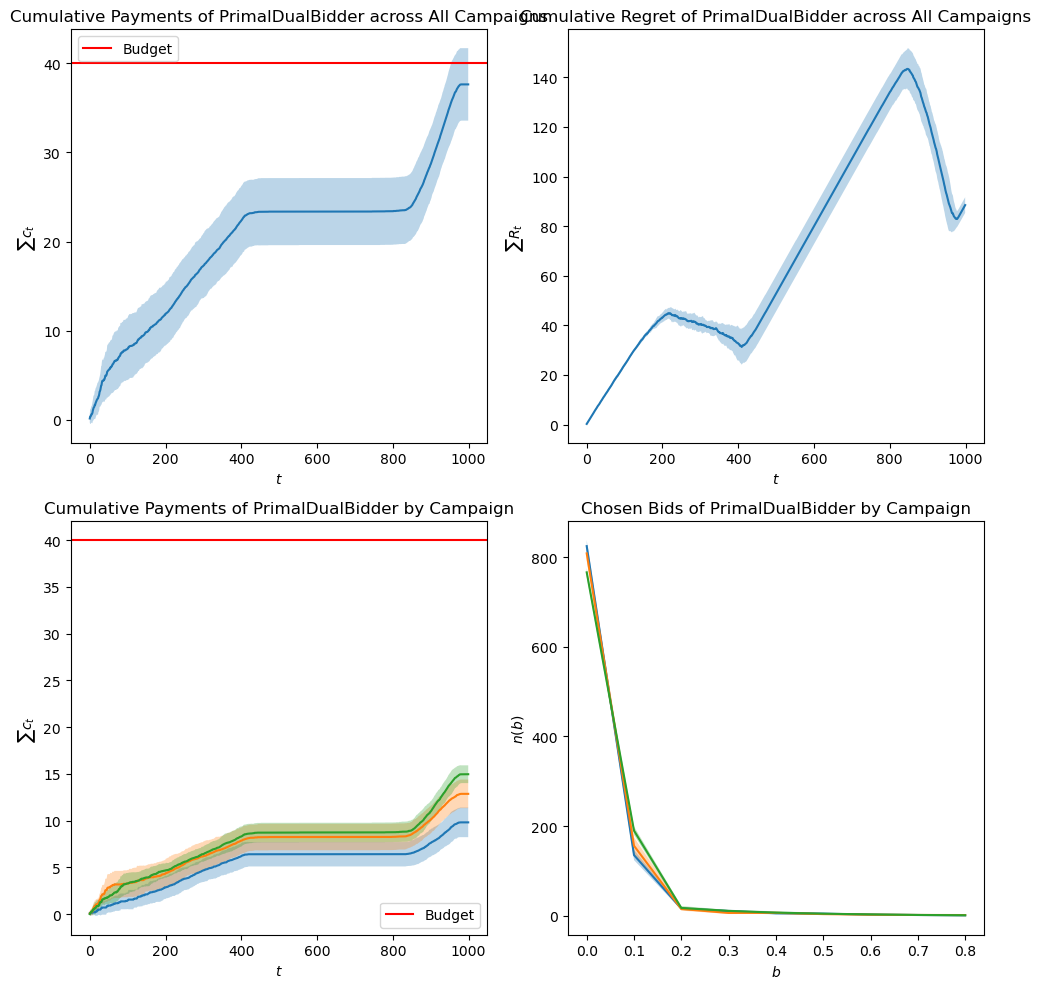

In [45]:
STARTING_BUDGET = RHO * N_USERS     # or np.inf for no budget

MY_VALUATION = 0.8  # my true valuation of the ads (assumed to be known)

LEARNING_RATE_PRIMAL = 1
LEARNING_RATE_DUAL = 1

budget_constrained_multiple_campaigns_primal_dual_experiment = Experiment(environment=environment,
                                                          bidder_class=PrimalDualBidder, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': [MY_VALUATION for _ in range(environment.N_CAMPAIGNS)], 
                                                              'environment': environment,
                                                              'learning_rate_primal': LEARNING_RATE_PRIMAL,
                                                              'learning_rate_dual': LEARNING_RATE_DUAL
                                                            })

budget_constrained_multiple_campaigns_primal_dual_experiment.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='simple')

# CAPIRE PERCHE' CLAIRVOYANT LP CRASHA SE RHO SOTTO QUELLO TROVATO DAL CLAIRVOYANT = 0.384